Accepted loans shape: (2260701, 151)
Rejected loans shape: (27648741, 9)
Default rate in accepted loans: 12.86%
Default counts: default
0    1969874
1     290827
Name: count, dtype: int64
modelling dataset: 
loan_amnt               33
term                    33
int_rate                33
installment             33
grade_num               33
dti                   1744
emp_length_years    146940
dtype: int64
missing values total: 
Final modeling dataset shape:  (2260701, 8)
Features:  7
Observations:  2260701
Train set:  1808560  samples
Test set:  452141  samples
Train default rate:  0.1286443358251869
Test default rate:  0.1286457100771662
Model has been trained. 
            Feature  Coefficient  Abs_Coefficient
4         grade_num     0.694529         0.694529
2          int_rate    -0.056048         0.056048
1              term     0.011180         0.011180
6  emp_length_years    -0.007528         0.007528
5               dti     0.003385         0.003385
3       installment     0.0

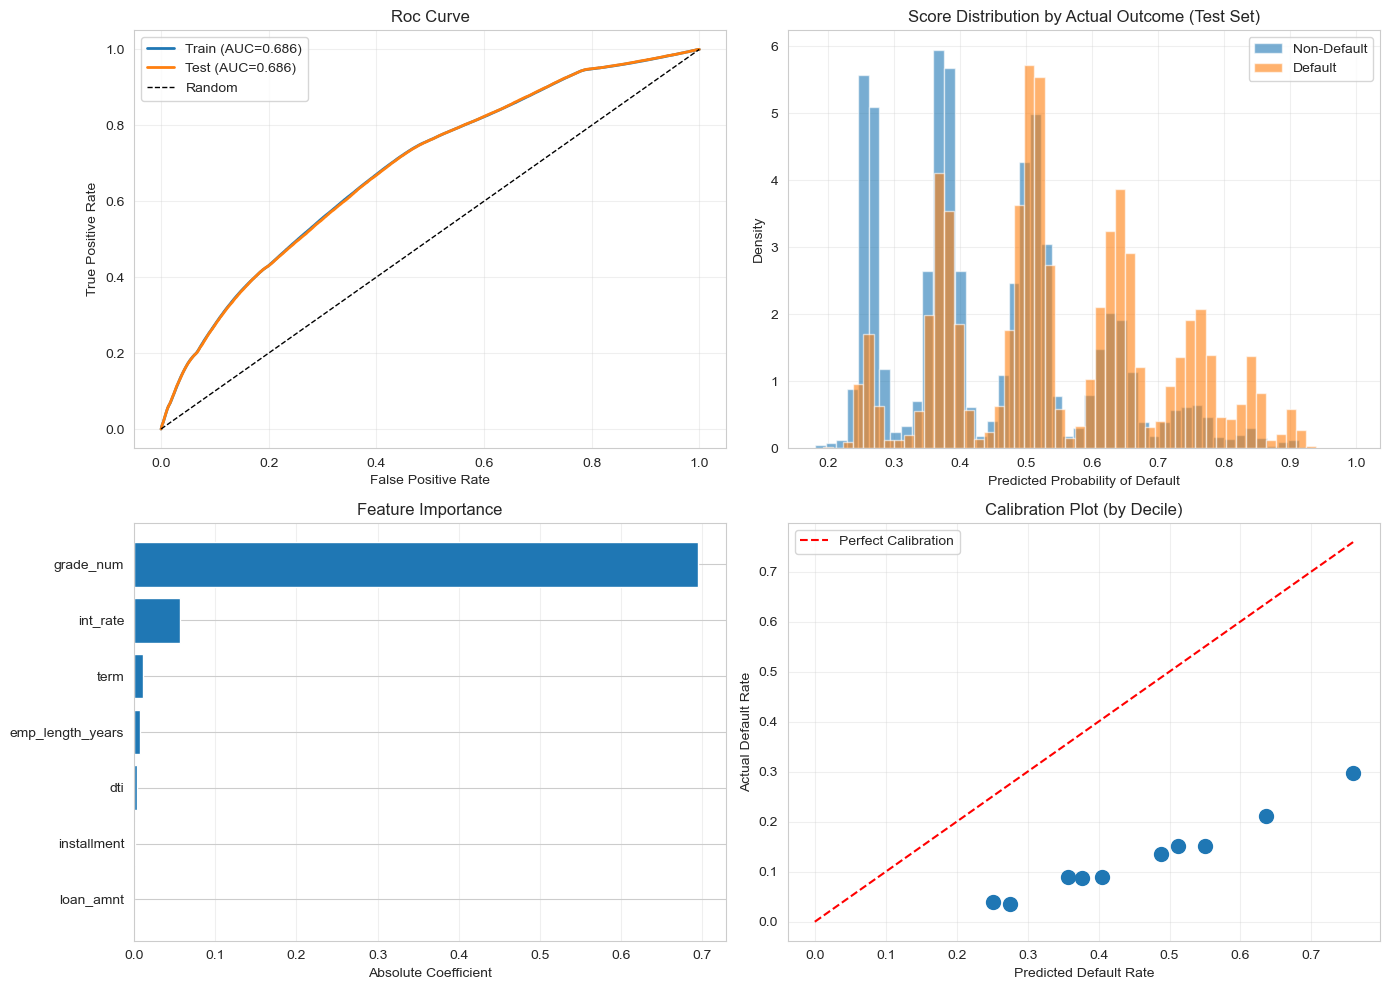

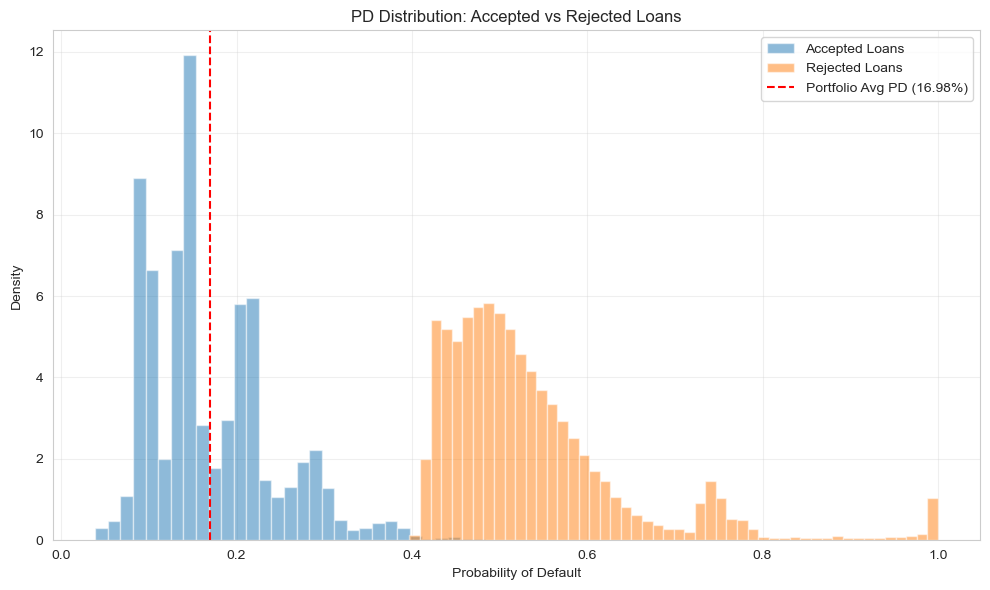

In [14]:
"""
Credit Risk Modeling Project, Enes
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, roc_curve, classification_report
import warnings
import os
warnings.filterwarnings('ignore')
sns.set_style("whitegrid")

accepted_df = pd.read_csv(r'C:/Users/TESLA/Desktop/datasets/risk_credit/accepted_2007_to_2018Q4.csv.gz')
rejected_df = pd.read_csv(r'C:/Users/TESLA/Desktop/datasets/risk_credit/rejected_2007_to_2018Q4.csv.gz')
print(f"Accepted loans shape: {accepted_df.shape}")
print(f"Rejected loans shape: {rejected_df.shape}")
accepted = accepted_df.copy()
rejected = rejected_df.copy()

accepted["term"] = (accepted["term"].astype(str).str.extract(r"(\d+)").astype(float))
accepted["int_rate"] = (accepted["int_rate"].astype(str).str.replace("%", "", regex=False).astype(float))


grade_map = {g: i for i, g in enumerate("ABCDEFG")}
accepted["grade_num"] = accepted["grade"].map(grade_map)

default_status = ["Charged Off", "Default","Late (31-120 days)", "Does not meet the credit policy. Status:Charged Off"]
accepted["default"] = accepted["loan_status"].isin(default_status).astype(int)

print(f"Default rate in accepted loans: {accepted['default'].mean():.2%}")
print(f"Default counts: {accepted['default'].value_counts()}")

#debt to Income
accepted['dti'] = pd.to_numeric(accepted['dti']) #, errors='coerce'
accepted['dti_high'] = (accepted['dti'] > 30).astype(int)

def clean_emp_length(emp):
    """Convert employment length to numeric years"""
    if pd.isna(emp):
        return np.nan
    emp = str(emp).lower()
    if '< 1' in emp or 'less than 1' in emp:
        return 0.5
    elif '10+' in emp or '10 years' in emp:
        return 10
    else:
        import re
        match = re.search(r'(\d+)', emp)
        return float(match.group(1)) if match else np.nan

accepted['emp_length_years'] = accepted['emp_length'].apply(clean_emp_length)
feature_cols = [
    "loan_amnt","term","int_rate","installment","grade_num","dti","emp_length_years"]

print("modelling dataset: ")

data = accepted[feature_cols + ["default"]].copy()

for col in feature_cols:
    data[col] = pd.to_numeric(data[col], errors="coerce")

# Checking missing datas
print(data[feature_cols].isnull().sum())
print("missing values total: ")
for col in feature_cols:
    if data[col].isnull().any():
        median_val = data[col].median()
        data[col].fillna(median_val, inplace=True)
        #print("Imputed {col} with median: median_val:")

data = data.dropna(subset=['default'])

print("Final modeling dataset shape: " , data.shape)
print("Features: ",len(feature_cols))
print("Observations: " , len(data))

x = data[feature_cols]
y = data["default"]

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)

print("Train set: " , x_train.shape[0] , " samples")
print("Test set: " , x_test.shape[0] , " samples")
print("Train default rate: " , y_train.mean())
print("Test default rate: " ,y_test.mean() )

pd_model = LogisticRegression(class_weight="balanced",  max_iter=1000, random_state=42, solver='lbfgs')

pd_model.fit(x_train, y_train)
print("Model has been trained. ")

coef_df = pd.DataFrame({'Feature': feature_cols,'Coefficient': pd_model.coef_[0], 'Abs_Coefficient': np.abs(pd_model.coef_[0])}).sort_values('Abs_Coefficient', ascending=False)
print(coef_df) #.to_string(index=False

y_train_pred_proba = pd_model.predict_proba(x_train)[:, 1]
y_test_pred_proba = pd_model.predict_proba(x_test)[:, 1]
train_auc = roc_auc_score(y_train, y_train_pred_proba)
test_auc = roc_auc_score(y_test, y_test_pred_proba)
train_gini = 2 * train_auc - 1
test_gini = 2 * test_auc - 1


print("Model Performance Metrics: ")
print(f"{'Metric':<20} {'Train':<12} {'Test':<12}")
print(f"{'AUC':<20} {train_auc:<12.4f} {test_auc:<12.4f}")
print(f"{'Gini Coefficient':<20} {train_gini:<12.4f} {test_gini:<12.4f}")

def calculate_ks(y_true, y_pred_proba):
    """Calculate KS statistic"""
    # Sort by predicted probability
    df = pd.DataFrame({'true': y_true, 'pred': y_pred_proba})
    df = df.sort_values('pred', ascending=False).reset_index(drop=True)
    
    df['bad_cumsum'] = df['true'].cumsum()
    df['good_cumsum'] = (1 - df['true']).cumsum()
    
    total_bads = df['true'].sum()
    total_goods = len(df) - total_bads
    
    df['bad_cumsum_pct'] = df['bad_cumsum'] / total_bads
    df['good_cumsum_pct'] = df['good_cumsum'] / total_goods
    
    df['ks'] = abs(df['bad_cumsum_pct'] - df['good_cumsum_pct'])
    ks_stat = df['ks'].max()
    
    return ks_stat

train_ks = calculate_ks(y_train, y_train_pred_proba)
test_ks = calculate_ks(y_test, y_test_pred_proba)

print(f"{'KS Statistic':<20} {train_ks:<12.4f} {test_ks:<12.4f}")

if abs(train_auc - test_auc) > 0.05:
    print("Significant gap between train and test auc, overfitting?)")
else:
    print("Model shows good generalization")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

fpr_train, tpr_train, _ = roc_curve(y_train, y_train_pred_proba)
fpr_test, tpr_test, _ = roc_curve(y_test, y_test_pred_proba)

axes[0, 0].plot(fpr_train, tpr_train, label=f'Train (AUC={train_auc:.3f})', linewidth=2)
axes[0, 0].plot(fpr_test, tpr_test, label=f'Test (AUC={test_auc:.3f})', linewidth=2)
axes[0, 0].plot([0, 1], [0, 1], 'k--', label='Random', linewidth=1)
axes[0, 0].set_xlabel('False Positive Rate')
axes[0, 0].set_ylabel('True Positive Rate')
axes[0, 0].set_title('Roc Curve')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].hist(y_test_pred_proba[y_test == 0], bins=50, alpha=0.6, 
                label='Non-Default', density=True)
axes[0, 1].hist(y_test_pred_proba[y_test == 1], bins=50, alpha=0.6, 
                label='Default', density=True)
axes[0, 1].set_xlabel('Predicted Probability of Default')
axes[0, 1].set_ylabel('Density')
axes[0, 1].set_title('Score Distribution by Actual Outcome (Test Set)')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

feature_importance = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': np.abs(pd_model.coef_[0])
}).sort_values('Importance', ascending=True)

axes[1, 0].barh(feature_importance['Feature'], feature_importance['Importance'])
axes[1, 0].set_xlabel('Absolute Coefficient')
axes[1, 0].set_title('Feature Importance')
axes[1, 0].grid(True, alpha=0.3, axis='x')

test_results = pd.DataFrame({
    'y_true': y_test.values,
    'y_pred': y_test_pred_proba
})
test_results['decile'] = pd.qcut(test_results['y_pred'], q=10, labels=False, duplicates='drop')
calibration = test_results.groupby('decile').agg({
    'y_pred': 'mean',
    'y_true': 'mean'
}).reset_index()

axes[1, 1].scatter(calibration['y_pred'], calibration['y_true'], s=100)
axes[1, 1].plot([0, calibration['y_pred'].max()], [0, calibration['y_pred'].max()], 
                'r--', label='Perfect Calibration')
axes[1, 1].set_xlabel('Predicted Default Rate')
axes[1, 1].set_ylabel('Actual Default Rate')
axes[1, 1].set_title('Calibration Plot (by Decile)')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)
OUTPUT_DIR = 'credit_risk_outputs'
plt.tight_layout()
output_path = os.path.join(OUTPUT_DIR, 'model_performance.png')
plt.savefig(output_path, dpi=300, bbox_inches='tight')

accepted = accepted.groupby("default", group_keys=False).apply(lambda x: x.sample(frac=0.2, random_state=42))
rejected = rejected.sample(frac=0.05, random_state=42)

x_all = accepted[feature_cols].copy()
for col in feature_cols:
    x_all[col] = pd.to_numeric(x_all[col], errors="coerce")
    if x_all[col].isnull().any():
        x_all[col].fillna(x_all[col].median(), inplace=True)



accepted['pd'] = pd_model.predict_proba(x_all)[:, 1]
accepted['pd_annual'] = 1 - (1 - accepted['pd']) ** (12 / accepted["term"])


#loss given default, 0.6 as parameter
LGD = 0.60

#exposure at default
accepted["ead"] = accepted["loan_amnt"]

accepted["expected_loss"] = accepted['pd_annual'] * LGD * accepted["ead"]

total_ead = accepted["ead"].sum()
total_el = accepted["expected_loss"].sum()
portfolio_el_rate = total_el / total_ead

print(f"\nPortfolio Metrics:")
print(f"{'Metric':<30} {'Value':<20}")
print("-" * 50)
print(f"{'Total EAD':<30} ${total_ead:,.0f}")
print(f"{'Total Expected Loss':<30} ${total_el:,.0f}")
print(f"{'Portfolio EL Rate':<30} {portfolio_el_rate:.2%}")
print(f"{'Average PD':<30} {accepted['pd_annual'].mean():.2%}")

el_by_grade = accepted.groupby('grade').agg({'ead': 'sum', 'expected_loss': 'sum', 'pd': 'mean', 'loan_amnt': 'count' }).round(2)
el_by_grade['el_rate'] = (el_by_grade['expected_loss'] / el_by_grade['ead'] * 100).round(2)
el_by_grade = el_by_grade.rename(columns={'loan_amnt': 'num_loans'})

print(f"Expected Loss by Grade:") ; print(el_by_grade)

accepted['ul_squared'] = (
    accepted['pd_annual'] * (1 - accepted['pd_annual']) * (LGD ** 2) * (accepted['ead'] ** 2)
)
unexpected_loss = np.sqrt(accepted['ul_squared'].sum())

confidence_level = 0.999
z_score = 3.09  #99.9% confidence
economic_capital = unexpected_loss * z_score

print(f"\nEconomic Capital Metrics:")
print(f"{'Metric':<35} {'Value':<20}")
print("-" * 55)
print(f"{'Expected Loss (EL)':<35} ${total_el:,.0f}")
print(f"{'Unexpected Loss (UL)':<35} ${unexpected_loss:,.0f}")
print(f"{'Economic Capital (99.9%)':<35} ${economic_capital:,.0f}")
print(f"{'EC as % of EAD':<35} {(economic_capital/total_ead)*100:.2f}%")

avg_int_rate = accepted['int_rate'].mean() / 100
expected_revenue = total_ead * avg_int_rate
expected_profit = expected_revenue - total_el
raroc = expected_profit / economic_capital

print(f"{'Expected Revenue':<35} ${expected_revenue:,.0f}")
print(f"{'Expected Profit (Revenue - EL)':<35} ${expected_profit:,.0f}")
print(f"{'RAROC':<35} {raroc:.2%}")


print("\nPreparing rejected loan data...")
rejected_common = rejected.copy()

print(f"Rejected dataset columns (first 10): {list(rejected.columns[:10])}")

feature_map = {
    'Amount Requested': 'loan_amnt', 'Debt-To-Income Ratio': 'dti', 'Employment Length': 'emp_length'}

for old_col, new_col in feature_map.items():
    if old_col in rejected.columns:
        rejected_common[new_col] = rejected[old_col]
        
if 'dti' in rejected_common.columns:
    rejected_common['dti'] = rejected_common['dti'].astype(str).str.replace('%', '').astype(float)

if 'emp_length' in rejected_common.columns:
    rejected_common['emp_length_years'] = rejected_common['emp_length'].apply(clean_emp_length)

reduced_features = ['loan_amnt', 'dti', 'emp_length_years']
available_features = [f for f in reduced_features if f in rejected_common.columns]
print(f"\nAvailable features for reject inference: {available_features}")

if len(available_features) >= 2:
    x_reduced = accepted[available_features].copy()
    for col in available_features:
        x_reduced[col] = pd.to_numeric(x_reduced[col], errors='coerce')
        x_reduced[col].fillna(x_reduced[col].median(), inplace=True)
    
    y_reduced = accepted['default']

    valid_idx = ~x_reduced.isnull().any(axis=1) & ~y_reduced.isnull()
    x_reduced = x_reduced[valid_idx]
    y_reduced = y_reduced[valid_idx]
    
    pd_model_reduced = LogisticRegression(
        class_weight="balanced",
        max_iter=1000,
        random_state=42
    )
    pd_model_reduced.fit(x_reduced, y_reduced)
    
    x_rejected = rejected_common[available_features].copy()
    for col in available_features:
        x_rejected[col] = pd.to_numeric(x_rejected[col], errors='coerce')
        x_rejected[col].fillna(x_rejected[col].median(), inplace=True)
    
    x_rejected = x_rejected.dropna()
    rejected_pd = pd_model_reduced.predict_proba(x_rejected)[:, 1]
    
    print(f"\n✓ Reject inference completed")
    print(f"Rejected loans analyzed: {len(rejected_pd):,}")
    print(f"\nRejected Loan PD Statistics:")
    print(f"{'Metric':<25} {'Value':<15}")
    print("-" * 40)
    print(f"{'Mean PD':<25} {rejected_pd.mean():.2%}")
    print(f"{'Median PD':<25} {np.median(rejected_pd):.2%}")
    print(f"{'25th Percentile':<25} {np.percentile(rejected_pd, 25):.2%}")
    print(f"{'75th Percentile':<25} {np.percentile(rejected_pd, 75):.2%}")
    
    # Compare accepted vs rejected PD dist
    print(f"\nComparison: Accepted vs Rejected")
    print(f"{'Metric':<25} {'Accepted':<15} {'Rejected':<15}")
    print("-" * 55)
    print(f"{'Mean PD':<25} {accepted['pd_annual'].mean():<15.2%} {rejected_pd.mean():<15.2%}")
    print(f"{'Median PD':<25} {accepted['pd_annual'].median():<15.2%} {np.median(rejected_pd):<15.2%}")

    good_reject_threshold = accepted['pd_annual'].mean()
    potentially_good_rejects = (rejected_pd < good_reject_threshold).sum()
    
    print(f"\n{'Potentially Good Rejects':<25} {potentially_good_rejects:,}")
    print(f"{'% of Rejected Loans':<25} {(potentially_good_rejects/len(rejected_pd))*100:.1f}%")
    
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.hist(accepted['pd_annual'], bins=50, alpha=0.5, label='Accepted Loans', density=True)
    ax.hist(rejected_pd, bins=50, alpha=0.5, label='Rejected Loans', density=True)
    ax.axvline(good_reject_threshold, color='r', linestyle='--', 
               label=f'Portfolio Avg PD ({good_reject_threshold:.2%})')
    ax.set_xlabel('Probability of Default')
    ax.set_ylabel('Density')
    ax.set_title('PD Distribution: Accepted vs Rejected Loans')
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    output_path = os.path.join(OUTPUT_DIR, 'reject_inference.png')
    plt.savefig(output_path, dpi=300, bbox_inches='tight')
    print(f"\n✓ Saved: {output_path}")
    
else:
    print("\Warning: Insufficient common features for reject inference")
    print("This is a common limitation with rejected loan datasets")


#SUMMARY 



summary = f"""
CREDIT RISK MODELING PROJECT: SUMMARY
=====================================

Dataset:
- Accepted loans: {len(accepted):,}
- Rejected loans: {len(rejected):,}
- Time period: 2007-2018 ,of the Lending Club 
- Default rates: {accepted['default'].mean():.2%}

Model Performance:
- Model is a logistic regression,
- Features: {len(feature_cols)}
- Test AUC: {test_auc:.4f}
- Test Gini: {test_gini:.4f}
- KS Statistic: {test_ks:.4f}

Risk Metrics are:
- Portfolio EL Rate: {portfolio_el_rate:.2%}
- Total Expected Loss: ${total_el:,.0f}
- Economic Capital (99.9%): ${economic_capital:,.0f}
- RAROC: {raroc:.2%}

important detail: 
{(potentially_good_rejects/len(rejected_pd) if len(available_features) >= 2 else 0)*100:.1f}% of rejected loans may have been acceptable
"""

print(summary)

summary_path = os.path.join(OUTPUT_DIR, 'project_summary.txt')
with open(summary_path, 'w') as f:
    f.write(summary)



In [13]:
print(accepted["default"].value_counts(normalize=True))

default
0    0.871355
1    0.128645
Name: proportion, dtype: float64
